#Project Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Libraries loaded.


#Initial Data Exploration

In [3]:
FILEPATH = "/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv"
df = pd.read_csv(FILEPATH)
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 55121 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#Features and targets are chosen
The features (X) and the targets (y) are chosen. Features are the things that the model uses to make a prediction, while targets are the things that we want the model to predict. In essence, the features are the clues that lead you to the target, the answer.

In [4]:
TARGET = "esi"

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [5]:
X = df[FEATURES]
y = df[TARGET]

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:6], "...")

Model will use 209 features to predict: esi
First few features: ['Unnamed: 0', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2'] ...


#Splitting into training and test sets
Train test split works by separating the testing and training data. In this case the test size is 20%(0.2), while the training data is the remaining 80%. Hiding some data from the model while training allows us to note the reproducibility of the model, as well as to compare it against what it did before. Additionally, random state is any whole number, and `stratify = y` keeps the ESI mix balanced amongst the two datasets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 25,
    stratify = y)

#Did this to verify X_train/test and y_train/test had the same value
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

#Did this to verify the actual numbers
print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

X_train: (44096, 209) y_train: (44096,)
X_test: (11025, 209) y_test: (11025,)
Training patients: 44096
Testing patients:  11025


#Beat the DummyClassifier as a Baseline
DummyClassifier is basically a baseline for the model that we're about to train and test. The dummy should be so bad that the trained model never becomes like it. If it's worse then something's wrong. The dummy is trained like any regular model, however, it ignores features, and instead, makes predictions on its own.

In [7]:
dummy = DummyClassifier(strategy = "stratified", random_state = 25)
dummy.fit(X_train, y_train)
print((dummy.score(X_test, y_test)))

0.3710657596371882


#M1 - Logistic Regression and Standard Scaler
Standard sclaer aims to transform each feature such that bigger ranges don't overpower smaller ranges. For example, heart rate is typically on a scale of 80 - 120, however, respiratory rate is usually between 20 - 25. As such, without logistic regression the model would treat every respiratory rate as an anomaly.

On the other hand, logistic regression is a classification algorithm that predicts the chance that a sample belongs to a class. It adds all the features into one score that it passed through the logistic (sigmoid) function. This function puts it into a probability between 0 and 1. Scores above 0.5 indicate one class, while the vice versa is true for the other class.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter = 1000, random_state = 25)
logreg.fit(X_train_scaled, y_train)
print(logreg.score(X_test_scaled, y_test))

0.6743764172335601


#M2 - Decision Tree
Decision trees show you how models arrived at an answer via a series of true/false outputs being split down different branches. The max depth is how many questions deep the tree goes. A small tree has a lower max depth, while the vice versa is true for a big tree. Decision trees are a good way to visualize what and how the model thought after giving the clinician the outputs.

In [9]:
tree = DecisionTreeClassifier(max_depth = 5, random_state = 42)
tree.fit(X_train, y_train)
print(tree.score(X_test, y_test))

0.5560090702947846


##Model Visualization
The figure on the right shows the threshold at 0.5. At that value, there is a cutoff that separates the two classes.

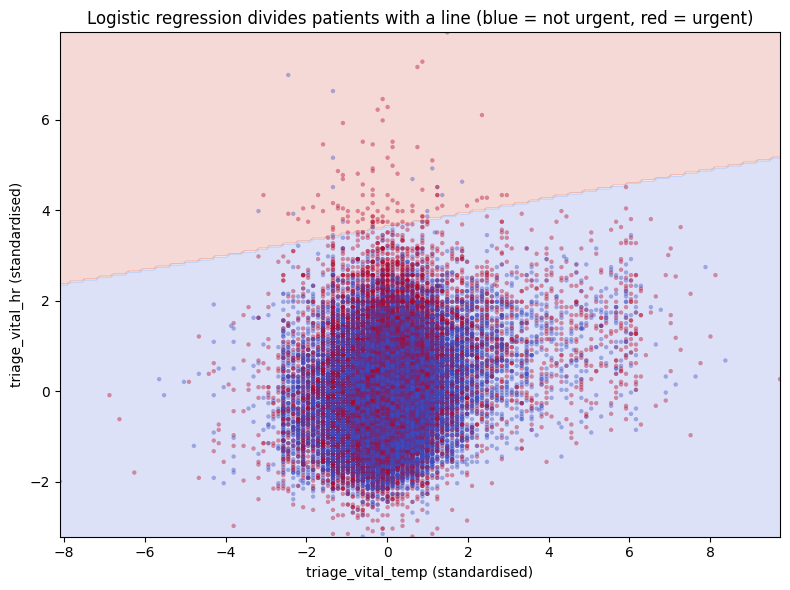

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Pick two features for the x and y axes, try swapping these, or try new combos
f1, f2 = "triage_vital_temp", "triage_vital_hr"

urgent = (y <= 2).astype(int)

two = StandardScaler().fit_transform(X[[f1, f2]])

demo = LogisticRegression(max_iter=1000).fit(two, urgent)

xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")
ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("Logistic regression divides patients with a line (blue = not urgent, red = urgent)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/w6_logreg_boundary.png", dpi=120, bbox_inches="tight")
plt.show()

#The Flowchart
As mentioned before, the decision tree is a series of true/false outputs, similar to a flowchart. Due to the ability to trace the source and destination of the model's thoughts, its easier for cinicians to follow, be ethical in their decision and note why the model came at such a deicison.

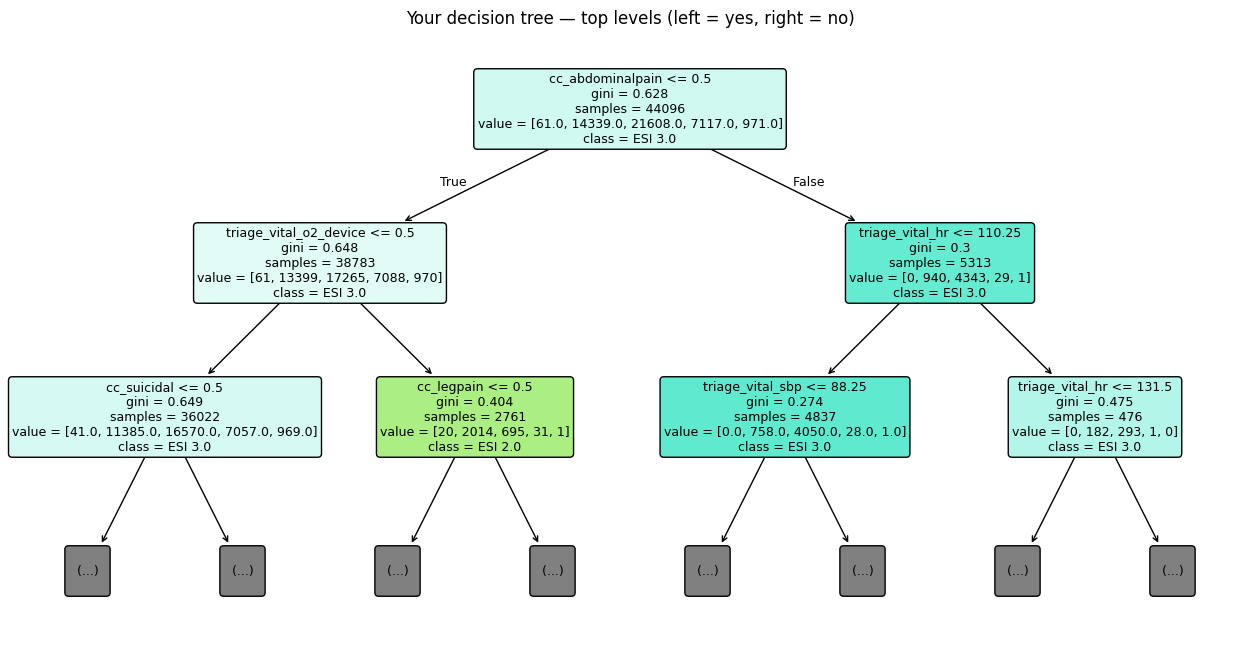

In [14]:
from sklearn.tree import plot_tree
import os

os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=[f"ESI {c}" for c in tree.classes_],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=9,
    ax=ax,
)
ax.set_title("Your decision tree — top levels (left = yes, right = no)")
plt.savefig("/content/drive/MyDrive//w6_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.tree import export_text
print(export_text(tree, feature_names=list(FEATURES), max_depth=2))

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- cc_legpain >  0.50
|   |   |   |--- truncated branch of depth 3
|--- cc_abdominalpain >  0.50
|   |--- triage_vital_hr <= 110.25
|   |   |--- triage_vital_sbp <= 88.25
|   |   |   |--- truncated branch of depth 3
|   |   |--- triage_vital_sbp >  88.25
|   |   |   |--- truncated branch of depth 3
|   |--- triage_vital_hr >  110.25
|   |   |--- triage_vital_hr <= 131.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- triage_vital_hr >  131.50
|   |   |   |--- truncated branch of depth 3



#Saving the Models

In [13]:
#This freezes a trained model to storage so it can be reloaded later.
joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree,   "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib")

#Reload each file back into a variable:
logreg_reloaded = joblib.load("model_logreg.joblib")   # the trained logistic regression
tree_reloaded   = joblib.load("model_tree.joblib")     # the trained decision tree
scaler_reloaded = joblib.load("scaler.joblib")         # the SAME scaler used in training

#Use them exactly like before. Remember: logistic regression needs SCALED
#features, so scale first with the reloaded scaler, then predict.
example = X_test.iloc[:5]                               # 5 patients as a demo
example_scaled = scaler_reloaded.transform(example)     # scale with the reloaded scaler
print("Reloaded logreg predictions:", logreg_reloaded.predict(example_scaled))

#The decision tree uses UNSCALED features, so pass the raw rows straight in.
print("Reloaded tree   predictions:", tree_reloaded.predict(example))

#Quick sanity check that the reloaded model matches the original one:
print("Reloaded model matches original?",
      (logreg_reloaded.predict(example_scaled) == logreg.predict(scaler.transform(example))).all())

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib
Reloaded logreg predictions: [3. 3. 3. 3. 3.]
Reloaded tree   predictions: [3. 3. 3. 3. 3.]
Reloaded model matches original? True
